# S10-1 イミュナイゼーションとALM

## 学習目標

- サープラス $S(y)=A(y)-L(y)$ のテイラー展開から、免疫化（Redington）の3条件
  ——現在価値一致・ドルデュレーション一致・資産コンベクシティ≥負債——を導出し、
  平行シフトに対して余剰が非負になることを証明レベルで説明できる
- 所与の負債キャッシュフローに対し、資産デュレーション＝負債デュレーション・
  コンベクシティ≥負債・現在価値一致を満たす免疫化ポートフォリオを、線形計画
  （`scipy.optimize.linprog`）で最小コスト構築できる
- 免疫化定理が「平行シフト」を仮定していること、カーブのツイスト（非平行変形）
  では成立が破れる仕組みを、キーレートデュレーション（KRD）で分解して診断できる
- キャッシュフローマッチング（デディケーション）とデュレーションマッチングの
  費用対効果を、コストと金利変動耐性の観点で比較できる

## 実務での位置づけ（ファンドはどう稼ぐか）

年金基金や生命保険会社は、将来の給付・保険金という**負債**を先に背負い、その支払いを保有債券という**資産**で賄う ALM（資産負債総合管理）が運用の中心です。ここでの目標は「相場を当てて儲ける」ことではなく、金利が上下してもサープラス $S=A-L$ を崩さないことにあります。金利が動いたときに資産の値下がりが負債の値下がりを上回れば積立不足に転落し、追加拠出や保険料引き上げという実損が発生します。免疫化（Redington）はこの積立不足リスクを抑える技術で、資産のドルデュレーションを負債に一致させ、資産コンベクシティを負債以上にしておくことで、平行シフトに対してサープラスが非負に保たれます。運用会社にとっての価値は、この「負債を守る」設計そのものが顧客（年金・保険）への提供サービスであり、運用報酬の源泉になる点にあります。

もっとも、免疫化定理はカーブの平行シフトを仮定しています。実際のカーブは短期と長期で動きが違うツイスト（スティープ化・フラット化）を起こすため、全体のデュレーションを合わせただけでは、負債が集中する年限の金利だけが動いたときに免疫が破れます。実務ではキーレートデュレーション（KRD）で資産と負債のエクスポージャを年限ごとに分解し、負債のキャッシュフローが厚い年限に資産の感応度を張り付けます。これがキーレート免疫化で、単一デュレーションの免疫化より頑健です。

負債への合わせ方には段階があります。給付キャッシュフローを債券のキャッシュフローで直接埋めるキャッシュフローマッチング（デディケーション）は再投資リスクをほぼ消せますが、都合の良い年限・銘柄を集める必要があり高コストです。デュレーション（＋コンベクシティ）マッチングは少ない銘柄で近似できて安価ですが、非平行変形やリバランス頻度に応じた残余リスクを抱えます。運用の実務は、このコストと金利変動耐性のトレードオフを負債の性質（確定給付か・年限分布・許容できる積立比率の振れ）に合わせて選ぶ意思決定そのものです。本 notebook で扱う線形計画による最小コスト免疫化ポートフォリオの構築は、そのトレードオフを定量的に詰める道具になります（docs/債券ファンドの業務.md「運用会社・ALM」の枠組み）。


## 理論

### サープラスとALMの目的関数

年金基金や生命保険会社は、将来支払う給付・保険金（**負債**）を、保有する
債券等（**資産**）で賄う。資産・負債の現在価値をそれぞれ $A$, $L$ とし、

$$ S = A - L $$

を**サープラス**（surplus, 余剰）と呼ぶ。資産・負債はともに金利に感応するため、
金利 $y$ の関数として $A(y)$, $L(y)$, $S(y)=A(y)-L(y)$ と書く。ALM
（asset-liability management, 資産負債総合管理）の目的は、金利が動いても
サープラスが崩れない——理想的には $S$ を金利変動に対して不感応にする——ように
資産側を組むことにある。

### デュレーションマッチングとサープラスのテイラー展開

平坦な利回り $y$ が全キャッシュフローに共通に効く（フラットカーブ・平行シフト）
単純化のもとで、$A(y)$ を基準点 $y_0$ まわりにテイラー展開する。ドル
デュレーション $D^\$_A=-A'(y_0)$、ドルコンベクシティ $\Gamma_A=A''(y_0)$ を使うと

$$ A(y_0+\Delta) = A(y_0) - D^\$_A\,\Delta + \tfrac{1}{2}\Gamma_A\,\Delta^2 + o(\Delta^2). $$

負債も同様に展開し、差を取ると

$$ S(y_0+\Delta) = S(y_0) - \big(D^\$_A - D^\$_L\big)\Delta
     + \tfrac{1}{2}\big(\Gamma_A - \Gamma_L\big)\Delta^2 + o(\Delta^2). $$

ここで**ドルデュレーション** $D^\$ = P\cdot D_{\text{mod}}$（価格×修正
デュレーション）は $-dP/dy$、すなわち金利1単位あたりの価格変化額である。

### 免疫化（Redington）の3条件

上式の右辺を、任意の小さな平行シフト $\Delta$ に対して $S(y_0+\Delta)\ge 0$
にしたい。次の3条件を課す。

| 条件 | 数式 | 効果 |
|---|---|---|
| 現在価値一致 | $A(y_0)=L(y_0)$ | $S(y_0)=0$（初期サープラス0） |
| ドルデュレーション一致 | $D^\$_A=D^\$_L$ | 1次項が消える |
| コンベクシティ条件 | $\Gamma_A\ge \Gamma_L$ | 2次項が非負 |

このとき

$$ S(y_0+\Delta) = \tfrac{1}{2}\big(\Gamma_A - \Gamma_L\big)\Delta^2 + o(\Delta^2) \ \ge\ 0. $$

**平行シフトの向き（上昇・下降）によらず**サープラスは非負に保たれる。これが
**Redington の免疫化定理**である。1次項を消すのがデュレーションマッチング、
2次項の符号を保証するのがコンベクシティ条件で、両者は役割が異なる。
現在価値一致で $D^\$_A=D^\$_L$ は「資産と負債の**修正デュレーション**が等しい」
ことと同値になる（$A=L$ ゆえ $P_A D_A = P_L D_L \Rightarrow D_A=D_L$）。

資産・負債の（金額加重）デュレーション差 $D_A - D_L$ を**デュレーション
ギャップ**（duration gap）と呼ぶ。免疫化はギャップをゼロにする操作である。
ギャップが正なら金利上昇でサープラスが痩せ、負なら金利低下で痩せる。

### コンベクシティ条件が生む非対称性

$\Gamma_A > \Gamma_L$ を厳密に満たすと、平行シフトはむしろサープラスを
**増やす**（$\tfrac{1}{2}(\Gamma_A-\Gamma_L)\Delta^2>0$）。同じデュレーションでも、
キャッシュフローが両端に散った**バーベル**は、中央に集中した**ブレット**より
コンベクシティが高い。したがってコンベクシティ条件は「資産のCF分散を負債より
大きく取れ」と要求する。ただしこの分散こそが、次に述べるツイストでの弱点になる。

### 免疫化定理が破れる仕組み（証明レベル）

定理の証明は「$y$ が単一のスカラーで、全期間のレートが同量 $\Delta$ だけ動く
（平行シフト）」という仮定に全面的に依存する。現実のイールドカーブは各年限
$t$ のゼロレート $z(t)$ からなり、その変化 $\Delta(t)$ は年限で異なる（非平行）。

資産・負債の時点 $t$ のキャッシュフローを $a_t$, $l_t$、割引係数を $DF(t)$ と
すると、ゼロレートの微小変化 $\Delta(t)$ に対するサープラス変化の1次項は

$$ dS = -\sum_t \big(a_t - l_t\big)\, t\, DF(t)\, \Delta(t). $$

**平行シフト** $\Delta(t)\equiv\Delta$ のときだけ $\Delta$ を括り出せて

$$ dS = -\Delta \sum_t (a_t-l_t)\,t\,DF(t) = -\Delta\,(D^\$_A - D^\$_L) = 0 $$

となり、デュレーション一致で消える。しかし $\Delta(t)$ が年限で変わる**ツイスト**
では $\Delta(t)$ を括り出せず、たとえ総デュレーションが一致していても

$$ dS = -\sum_t (a_t-l_t)\,t\,DF(t)\,\Delta(t)\ \ne\ 0 $$

が一般に残る。$dS$ がゼロになるのは**すべての $t$ で** $a_t\,t\,DF(t)=l_t\,t\,DF(t)$、
つまり資産CFプロファイルが負債CFプロファイルに時点ごと一致するとき——
キャッシュフローマッチングのとき——に限る。単なるデュレーション一致は、
CFを1つの重心（デュレーション）にしか合わせておらず、重心まわりの**分散**
（どの年限にCFが散っているか）を放置している。この分散への感応度が
ツイストで露呈する。Fong-Vasicek はこの露出量を $M^2$（CFの負債重心まわりの
分散）として定式化し、免疫化リスクの尺度とした。

実務では $\Delta(t)$ を有限個のキーレート（2y, 5y, 10y, 20y, 30y 等）の変化に
分解し、各キーレート $i$ への感応度＝**キーレートデュレーション**（KRD）
$\kappa_i = -\partial P/\partial z_i$ を測る。上式は

$$ dS = -\sum_i \big(\kappa^A_i - \kappa^L_i\big)\,\Delta z_i $$

と離散化され、KRDミスマッチベクトル $\kappa^A_i-\kappa^L_i$ が各キーレートの
変化 $\Delta z_i$ と内積を取る形になる。総デュレーション一致は
$\sum_i(\kappa^A_i-\kappa^L_i)=0$（合計ゼロ）を意味するだけで、各バケットの
ミスマッチはゼロとは限らない。ツイスト（例：短期↓・長期↑）はこのバケット別
ミスマッチを突く。対策は各キーレートバケットでKRDを一致させる**キーレート
免疫化**（多点免疫化）、あるいは CF マッチングへ寄せることである。

### CFマッチング（デディケーション）との費用対効果

**キャッシュフローマッチング**（cash-flow matching, デディケーション）は、
各支払時点の負債CFを、資産のクーポン・償還で過不足なく賄うようにポートフォリオ
を組む手法である。理屈上は金利がどう動いても——平行でもツイストでも——資産CFで
負債を支払えるので、リバランス不要で金利リスクがゼロになる。一方で、

- 各時点を賄う制約が強く、選べる銘柄が限られるため**コストが高くなりやすい**
- 銘柄流動性・最小取引単位の制約で厳密一致は難しく、近似に留まる

デュレーションマッチング（免疫化）は制約が緩く**低コスト**だが、平行シフト以外
では上記のとおり破れ、定期的な**リバランス**を要する。実務は両者の中間——
キーレート免疫化やホライズンマッチング——を取ることが多い。年金ALMでは長い
負債に対し超長期債の供給が細く、完全なCFマッチングが物理的に組めないため、
デュレーション＋キーレート免疫化が主流である。生命保険では、予定利率保証や
解約オプションで負債CFが金利依存に変わるため、実効デュレーションでギャップを
管理する。

## スクラッチ実装

負債CFに対する最小コスト免疫化ポートフォリオを線形計画で解く。決定変数は各国債
の保有量 $w_i\ge 0$（額面100を1単位）。フラット利回り $y_0$ を基準に、各資産の
現在価値・修正デュレーション・コンベクシティは `bondlab.analytics.duration_convexity`
で求める。負債側は同一の割引規約で解析的に計算する。

$$
\begin{aligned}
\min_{w\ge 0}\ & \sum_i p^{\text{mkt}}_i\,w_i && \text{(市場コスト最小)}\\
\text{s.t.}\ & \sum_i p_i\,w_i = L && \text{(現在価値一致)}\\
             & \sum_i p_i D_i\,w_i = L\,D_L && \text{(ドルデュレーション一致)}\\
             & \sum_i p_i C_i\,w_i \ge L\,C_L && \text{(コンベクシティ条件)}
\end{aligned}
$$

$p_i$ はフェア価格（$y_0$ で評価）、$p^{\text{mkt}}_i$ は割高割安 `rich_cheap_bp`
を利回りに織り込んだ市場価格である。フェア現在価値を一致させつつ市場コストを
最小化するので、割安（cheap）銘柄が優先的に選ばれる。目的・制約がすべて線形
なので、`scipy.optimize.linprog` で大域最適が確実に得られる。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `make_bond(row, settlement)` | ユニバース1行, 決済日 | `FixedRateBond` | 残存年数から満期日を作り債券を生成 |
| `cf_analytics(times, cfs, ytm, freq)` | 年数配列, CF配列, 利回り, 頻度 | dict(pv, modified, convexity) | 任意CF列の現在価値・修正デュレーション・コンベクシティ（`duration_convexity` と同一規約） |
| `asset_metrics(bonds, ytm, settlement)` | 債券リスト, 利回り, 決済日 | dict(price, dur, conv) | 各資産の指標を `duration_convexity` で一括計算 |
| `solve_immunization(...)` | 資産指標, 市場価格, 負債指標 | 保有量 `w` | 線形計画で最小コスト免疫化を解く |
| `curve_pv_assets(w, bonds, settlement, curve)` | 保有量, 債券, 決済日, カーブ | 資産PV | 割引カーブでの資産再評価（KRD用） |
| `curve_pv_liab(times, cfs, curve)` | 年数, CF, カーブ | 負債PV | 割引カーブでの負債再評価（KRD用） |
| `key_rate_durations(pv_fn, curve, tenors, size, width)` | PV関数, カーブ, キーレート, 幅, 三角幅 | KRD配列 | 各キーレートのバンプ差分でKRDを測る |
| `twist_curve(base, deltas, width)` | カーブ, (テナー,変化)列, 三角幅 | カーブ | 年限別バンプを重ねた非平行カーブ（実データ適用で定義） |
| `parallel_shift(base, d)` | カーブ, 変化幅 | カーブ | 全ゼロレートを一律ずらす真の平行シフト（実データ適用で定義） |

In [1]:
import os

os.environ.setdefault("MPLBACKEND", "Agg")

import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from scipy.optimize import linprog

from bondlab.bond import FixedRateBond
from bondlab.analytics import duration_convexity, bump_curve
from bondlab.curve import bootstrap_par

np.random.seed(0)

SETTLEMENT = dt.date(2026, 7, 1)   # 決済日（基準日）
FREQ = 2                            # 半年利払い（JGB慣行）
Y0 = 0.015                         # 免疫化を組む基準フラット利回り 1.5%
BP = 1e-4


def make_bond(row, settlement=SETTLEMENT):
    """ユニバース1行（maturity_years, coupon）から FixedRateBond を作る。

    残存年数を日数へ換算して満期日を定める。発行日は決済日に置き、決済時点で
    経過利子ゼロ（clean=dirty）の新発債として素直に扱う。
    """
    mat = settlement + dt.timedelta(days=round(365.25 * row["maturity_years"]))
    return FixedRateBond(
        issue=settlement,
        maturity=mat,
        coupon=float(row["coupon"]),
        frequency=FREQ,
        convention="ACT/ACT",
        face=100.0,
    )


def cf_analytics(times, cfs, ytm, freq=FREQ):
    """任意のキャッシュフロー列の現在価値・修正デュレーション・コンベクシティ。

    `bondlab.analytics.duration_convexity` と同一の street convention で計算する。
    期間指数 n = freq·t（年数×頻度）を使い、割引は (1+y/freq)^{-n}。負債CFと
    資産CFを完全に同じ土俵で比較するための共通エンジン。
    """
    times = np.asarray(times, dtype=float)
    cfs = np.asarray(cfs, dtype=float)
    n = times * freq
    disc = (1.0 + ytm / freq) ** (-n)
    pv = float((cfs * disc).sum())
    macaulay = float((times * cfs * disc).sum() / pv)
    modified = macaulay / (1.0 + ytm / freq)
    d2 = (cfs * n * (n + 1.0) * (1.0 + ytm / freq) ** (-n - 2.0)).sum() / (freq ** 2)
    convexity = float(d2 / pv)
    return dict(pv=pv, macaulay=macaulay, modified=modified, convexity=convexity)


def asset_metrics(bonds, ytm, settlement=SETTLEMENT):
    """各資産の (フェア価格, 修正デュレーション, コンベクシティ) を配列で返す。

    リスク指標は bondlab.analytics.duration_convexity をそのまま使う。
    """
    price, dur, conv = [], [], []
    for b in bonds:
        m = duration_convexity(b, ytm, settlement)
        price.append(m["dirty_price"])
        dur.append(m["modified"])
        conv.append(m["convexity"])
    return dict(price=np.array(price), dur=np.array(dur), conv=np.array(conv))


def solve_immunization(price, dur, conv, mkt_price, L_pv, L_dur, L_conv):
    """最小コスト免疫化を線形計画で解く。返り値は保有量ベクトル w（>=0）。

    等式：現在価値一致・ドルデュレーション一致。不等式：コンベクシティ≥負債。
    目的：市場コスト最小。infeasible なら linprog が status!=0 を返す。
    """
    A_eq = np.vstack([
        price,                 # Σ p_i w_i = L_pv
        price * dur,           # Σ p_i D_i w_i = L_pv * L_dur
    ])
    b_eq = np.array([L_pv, L_pv * L_dur])
    # コンベクシティは下限制約 → -Σ p_i C_i w_i <= -L_pv*L_conv
    A_ub = -(price * conv)[None, :]
    b_ub = np.array([-L_pv * L_conv])
    res = linprog(
        c=mkt_price,
        A_ub=A_ub, b_ub=b_ub,
        A_eq=A_eq, b_eq=b_eq,
        bounds=[(0, None)] * len(price),
        method="highs",
    )
    if not res.success:
        raise RuntimeError(f"免疫化 LP が解けない: {res.message}")
    return res.x


def curve_pv_assets(w, bonds, settlement, curve):
    """割引カーブで資産ポートフォリオ全体の現在価値を再評価する（KRD/ツイスト用）。"""
    total = 0.0
    for wi, b in zip(w, bonds):
        if wi <= 0:
            continue
        for d, c in b.cashflows():
            if d > settlement:
                t = (d - settlement).days / 365.25
                total += wi * c * curve.discount(t)
    return total


def curve_pv_liab(times, cfs, curve):
    """割引カーブで負債キャッシュフローの現在価値を再評価する。"""
    return float(np.sum([c * curve.discount(t) for t, c in zip(times, cfs)]))


def key_rate_durations(pv_fn, curve, tenors, size=1e-4, width=2.0):
    """各キーレートを ±size バンプした中心差分で KRD（ドル額）を測る。

    KRD_i = -(PV(z_i+size) - PV(z_i-size)) / (2·size)。bump_curve は width 幅で
    テナーへ三角減衰するバンプを作る。合計はほぼ総ドルデュレーション（平行）。
    """
    out = []
    for T in tenors:
        up = bump_curve(curve, T, size, width=width)
        dn = bump_curve(curve, T, -size, width=width)
        out.append(-(pv_fn(up) - pv_fn(dn)) / (2.0 * size))
    return np.array(out)

自作エンジン `cf_analytics` が bondlab の `duration_convexity` と一致することを、
1銘柄の自身のキャッシュフローを流し込んで確認する。以降、負債も資産もこの共通
規約で扱えることの担保になる。

In [2]:
_probe = FixedRateBond(SETTLEMENT, SETTLEMENT + dt.timedelta(days=round(365.25 * 10)),
                       coupon=0.016, frequency=FREQ, convention="ACT/ACT")
_ref = duration_convexity(_probe, Y0, SETTLEMENT)
_n, _cf = _probe.period_cashflows(SETTLEMENT)
_mine = cf_analytics(_n / FREQ, _cf, Y0, FREQ)
print(f"duration_convexity : mod={_ref['modified']:.6f}  conv={_ref['convexity']:.6f}  pv={_ref['dirty_price']:.6f}")
print(f"cf_analytics(自作)  : mod={_mine['modified']:.6f}  conv={_mine['convexity']:.6f}  pv={_mine['pv']:.6f}")
assert abs(_ref["modified"] - _mine["modified"]) < 1e-10
assert abs(_ref["convexity"] - _mine["convexity"]) < 1e-10
assert abs(_ref["dirty_price"] - _mine["pv"]) < 1e-10
print("一致：自作エンジンは duration_convexity と同一規約")

duration_convexity : mod=9.215808  conv=93.634734  pv=100.925401
cf_analytics(自作)  : mod=9.215808  conv=93.634734  pv=100.925401
一致：自作エンジンは duration_convexity と同一規約


合成の年金負債を作る。加入者コホートの給付支払いを想定し、支払いは1年目から
立ち上がり中盤でピーク、その後逓減する25年の年次CF列とする。負債指標は基準
利回り $y_0$ で評価する。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


負債 現在価値 L      = 2129.61
負債 修正デュレーション D_L = 10.416 年
負債 コンベクシティ  C_L = 144.565


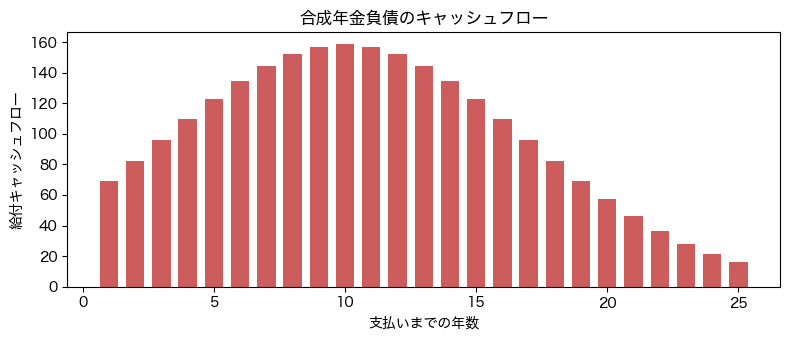

In [3]:
liab_times = np.arange(1.0, 26.0)                      # 1〜25年
_shape = np.exp(-0.5 * ((liab_times - 10.0) / 7.0) ** 2)  # 中盤ピークの給付プロファイル
liab_cfs = 100.0 * _shape / _shape.sum() * 25.0        # 規模を調整（合計 ~2500）

L = cf_analytics(liab_times, liab_cfs, Y0, FREQ)
print(f"負債 現在価値 L      = {L['pv']:.2f}")
print(f"負債 修正デュレーション D_L = {L['modified']:.3f} 年")
print(f"負債 コンベクシティ  C_L = {L['convexity']:.3f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(liab_times, liab_cfs, width=0.7, color="indianred")
ax.set_xlabel("支払いまでの年数")
ax.set_ylabel("給付キャッシュフロー")
ax.set_title("合成年金負債のキャッシュフロー")
fig.tight_layout()
plt.show()

実在風の国債ユニバースを読み込み、各銘柄の債券オブジェクトとリスク指標を作る。
フェア価格は $y_0$、市場価格は割高割安 `rich_cheap_bp` を利回りに足して評価する
（cheap＝利回り高＝価格安）。

In [4]:
universe = pd.read_csv("data/samples/synthetic_jgb_universe.csv")
bonds = [make_bond(r) for _, r in universe.iterrows()]

fair = asset_metrics(bonds, Y0, SETTLEMENT)
# 市場価格：各銘柄の利回りを rich_cheap_bp だけずらして再評価
mkt_price = np.array([
    duration_convexity(b, Y0 + rc * BP, SETTLEMENT)["dirty_price"]
    for b, rc in zip(bonds, universe["rich_cheap_bp"].values)
])

print("ユニバース銘柄数:", len(bonds))
print(f"資産デュレーション範囲: {fair['dur'].min():.2f}〜{fair['dur'].max():.2f} 年")
print(f"負債デュレーション   : {L['modified']:.2f} 年（範囲内 → 免疫化は実現可能）")

ユニバース銘柄数: 40
資産デュレーション範囲: 1.49〜23.32 年
負債デュレーション   : 10.42 年（範囲内 → 免疫化は実現可能）


免疫化ポートフォリオを線形計画で解く。3条件（現在価値一致・デュレーション一致・
コンベクシティ≥負債）を満たす中で市場コストが最小になる保有量を得る。

In [5]:
w = solve_immunization(
    fair["price"], fair["dur"], fair["conv"], mkt_price,
    L["pv"], L["modified"], L["convexity"],
)

held = w > 1e-6
port = pd.DataFrame({
    "bond_id": universe["bond_id"].values[held],
    "maturity_years": universe["maturity_years"].values[held],
    "coupon": universe["coupon"].values[held],
    "units": w[held],
    "fair_value": (w * fair["price"])[held],
})
port = port.sort_values("maturity_years")
print("免疫化ポートフォリオ（保有銘柄）:")
display(port.round(3))

A_pv = float(w @ fair["price"])
A_dur = float((w * fair["price"] * fair["dur"]).sum() / A_pv)
A_conv = float((w * fair["price"] * fair["conv"]).sum() / A_pv)
print(f"\n資産PV   = {A_pv:.2f}   (負債PV {L['pv']:.2f})")
print(f"資産D    = {A_dur:.3f}  (負債D  {L['modified']:.3f})   デュレーションギャップ = {A_dur - L['modified']:+.2e}")
print(f"資産C    = {A_conv:.3f}  (負債C  {L['convexity']:.3f})   コンベクシティ余裕 = {A_conv - L['convexity']:+.3f}")
assert abs(A_pv - L["pv"]) < 1e-4
assert abs(A_dur - L["modified"]) < 1e-6
assert A_conv >= L["convexity"] - 1e-9
print("免疫化3条件を満たす")

免疫化ポートフォリオ（保有銘柄）:


,bond_id,maturity_years,coupon,units,fair_value
0,JGB000,1.346,0.005,12.602,1241.584
1,JGB038,28.476,0.016,8.680,888.026



資産PV   = 2129.61   (負債PV 2129.61)
資産D    = 10.416  (負債D  10.416)   デュレーションギャップ = -3.02e-14
資産C    = 256.481  (負債C  144.565)   コンベクシティ余裕 = +111.915
免疫化3条件を満たす


最小コスト解は年限の両端に寄った**バーベル**になりやすい。短期と長期でデュレー
ションを合わせるとコンベクシティが高く（条件を余裕で満たし）、割安銘柄を拾える
ためである。このバーベル性が、後のツイストでの弱点になる。

## QuantLib検証

免疫化ポートフォリオの構築（線形計画）と、その金利変動耐性の検証は、QuantLib
の債券・デリバティブ評価が扱う守備範囲の外にある。QuantLib と価格を突合する
代わりに、ここでは**免疫化の効き目そのもの**を数値シミュレーションで検証する。
検証の位置づけは「免疫化理論の帰結——平行シフト $\pm100\text{bp}$ でサープラスが
保存（非負）され、免疫化直後のサープラス感応度がゼロ近傍になること——を、
実際に価格を振って確かめる」ことであり、特定市場での運用損益を保証するもの
ではない。

### 検証1：免疫化直後のサープラス感応度がゼロ近傍

フラット利回り $y_0$ を微小に振り、$dS/dy \approx 0$ を中心差分で確認する。
デュレーション一致（1次項の消去）が効いていれば、感応度はゼロ近傍に落ちる。

In [6]:
def surplus_flat(y):
    """フラット利回り y でのサープラス（資産dirty価格の合計 − 負債PV）。"""
    a = float(np.sum([wi * b.dirty_price(y, SETTLEMENT) for wi, b in zip(w, bonds) if wi > 0]))
    l = cf_analytics(liab_times, liab_cfs, y, FREQ)["pv"]
    return a - l


h = 1e-5
dSdy = (surplus_flat(Y0 + h) - surplus_flat(Y0 - h)) / (2 * h)
# 比較用：デュレーション未調整の素朴ポートフォリオ（負債と同PVの10年単一銘柄）
naive_bond = make_bond(pd.Series({"maturity_years": 10.0, "coupon": 0.016}))
naive_units = L["pv"] / duration_convexity(naive_bond, Y0, SETTLEMENT)["dirty_price"]
def surplus_naive(y):
    return naive_units * naive_bond.dirty_price(y, SETTLEMENT) - cf_analytics(liab_times, liab_cfs, y, FREQ)["pv"]
dSdy_naive = (surplus_naive(Y0 + h) - surplus_naive(Y0 - h)) / (2 * h)

print(f"免疫化   dS/dy = {dSdy:+.4f}   （PV {L['pv']:.1f} に対し ~0）")
print(f"素朴(10y) dS/dy = {dSdy_naive:+.4f}   （デュレーションギャップが残る）")
assert abs(dSdy) < 1e-2
print("検証1 合格：免疫化直後のサープラス感応度はゼロ近傍")

免疫化   dS/dy = -0.0002   （PV 2129.6 に対し ~0）
素朴(10y) dS/dy = +2554.9562   （デュレーションギャップが残る）
検証1 合格：免疫化直後のサープラス感応度はゼロ近傍


### 検証2：±100bp 平行シフトでサープラスが保存（非負）

免疫化理論は「$D^\$_A=D^\$_L$ かつ $\Gamma_A\ge\Gamma_L$ なら、平行シフトで
サープラスは非負」を主張する。$\pm100\text{bp}$ を含む範囲で $S(y)$ を実際に
描き、免疫化ポートフォリオが谷（$S\ge0$）を保つのに対し、素朴ポートフォリオは
片側で $S<0$ に沈むことを確認する。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


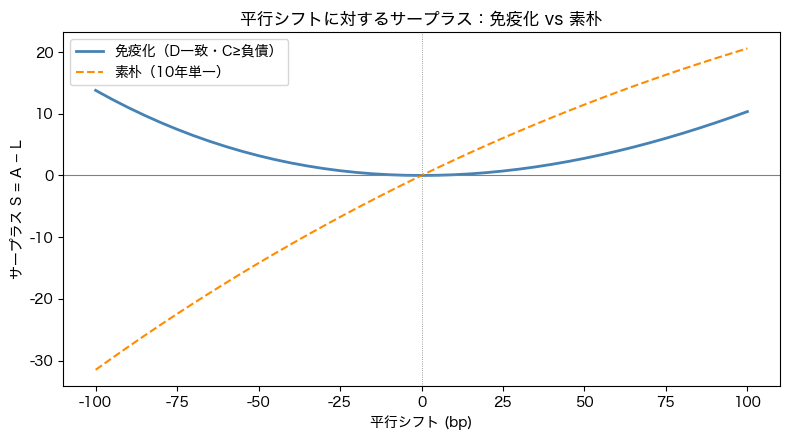

In [7]:
shifts = np.linspace(-0.01, 0.01, 41)
S_imm = np.array([surplus_flat(Y0 + d) for d in shifts])
S_naive = np.array([surplus_naive(Y0 + d) for d in shifts])

print(f"免疫化   サープラス: {shifts[0]*1e4:+.0f}bp → {S_imm[0]:+.3f},  0bp → {S_imm[20]:+.3f},  {shifts[-1]*1e4:+.0f}bp → {S_imm[-1]:+.3f}")
print(f"素朴(10y) サープラス: {shifts[0]*1e4:+.0f}bp → {S_naive[0]:+.3f},  0bp → {S_naive[20]:+.3f},  {shifts[-1]*1e4:+.0f}bp → {S_naive[-1]:+.3f}")
assert S_imm.min() > -1e-4, "免疫化ポートフォリオのサープラスが負に沈んだ"
print("検証2 合格：免疫化ポートフォリオは ±100bp 平行シフトでサープラス非負を保持")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(shifts * 1e4, S_imm, color="steelblue", lw=2, label="免疫化（D一致・C≥負債）")
ax.plot(shifts * 1e4, S_naive, color="darkorange", lw=1.5, ls="--", label="素朴（10年単一）")
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.6, ls=":")
ax.set_xlabel("平行シフト (bp)")
ax.set_ylabel("サープラス S = A − L")
ax.set_title("平行シフトに対するサープラス：免疫化 vs 素朴")
ax.legend()
fig.tight_layout()
plt.show()

免疫化の曲線は $y_0$ で $S=0$ に接し、両側でわずかに正へ持ち上がる。これが
コンベクシティ条件 $\Gamma_A>\Gamma_L$ の効果——$S\approx\tfrac12(\Gamma_A-\Gamma_L)\Delta^2\ge0$
——である。素朴ポートフォリオはデュレーションギャップのため一方向で沈む。

## 実データ適用

ここまでは「フラットカーブ・平行シフト」の理想世界だった。実際のカーブは年限で
形が異なり、平行以外の**ツイスト**で免疫化が破れる。割引カーブを組み、KRD で
資産・負債の年限別感応度を分解して、破れの発生源を診断する。

等間隔（年次）グリッドのパー利回りから割引カーブをブートストラップする。
`bootstrap_par` は等間隔グリッド前提のため、1〜30年の1年刻みで渡す（非等間隔
だと警告が出る仕様）。基準は免疫化を組んだ $y_0$ に合わせたフラットカーブとし、
カーブ評価でもサープラス初期値がほぼ0で始まるようにする（割引規約の差でごく
小さな残差は残る）。

In [8]:
tenors_grid = np.arange(1.0, 31.0)                       # 等間隔（1年刻み）
par_rates = np.full_like(tenors_grid, Y0)                # フラット（y0 = 1.5%）
curve = bootstrap_par(tenors_grid, par_rates, frequency=1, interp="log_linear")

# カーブ上での資産・負債PV（KRDの土台）
pv_a = lambda cv: curve_pv_assets(w, bonds, SETTLEMENT, cv)
pv_l = lambda cv: curve_pv_liab(liab_times, liab_cfs, cv)
print(f"カーブ評価 資産PV = {pv_a(curve):.2f}   負債PV = {pv_l(curve):.2f}")

カーブ評価 資産PV = 2133.99   負債PV = 2130.85


資産・負債のキーレートデュレーションを主要年限で測り、感応度が年限のどこに
分布しているか（プロファイルの形）を比較する。総ドルデュレーションが一致して
いても、バケット別プロファイルがずれていれば、それがツイスト露出になる。
なお、選んだキーレート（2/5/10/20/30年, 幅3年）は年限を隙間なく覆わないため、
バケットKRDの単純合計は総デュレーションには一致しない。ここでは合計ではなく
**形の違い**の指標として読む。

キーレートデュレーション（ドル額, カーブ評価）:


,key_tenor,KRD_asset,KRD_liab,mismatch
0,2.0,1481.03,527.14,953.89
1,5.0,192.60,1733.15,-1540.54
2,10.0,358.31,4032.55,-3674.23
3,20.0,618.18,2552.37,-1934.18
4,30.0,8133.86,-0.00,8133.86


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


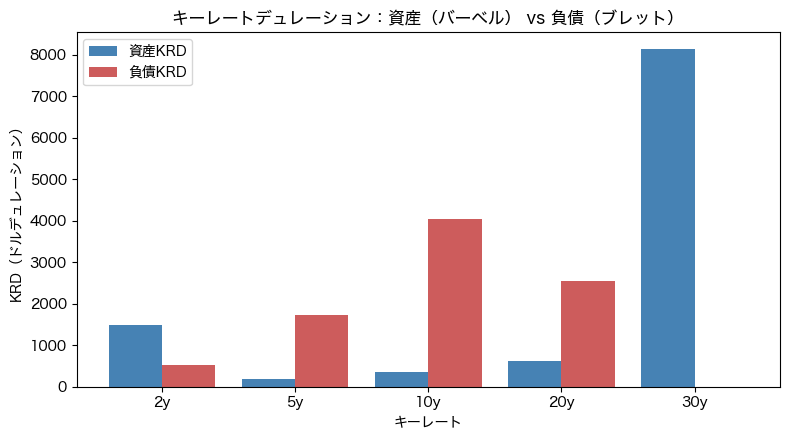

In [9]:
key_tenors = np.array([2.0, 5.0, 10.0, 20.0, 30.0])
krd_a = key_rate_durations(pv_a, curve, key_tenors, size=BP, width=3.0)
krd_l = key_rate_durations(pv_l, curve, key_tenors, size=BP, width=3.0)

krd_tbl = pd.DataFrame({
    "key_tenor": key_tenors,
    "KRD_asset": krd_a,
    "KRD_liab": krd_l,
    "mismatch": krd_a - krd_l,
})
print("キーレートデュレーション（ドル額, カーブ評価）:")
display(krd_tbl.round(2))
print("\n資産は短期(2y)・長期(30y)に感応度が張り出すバーベル型、")
print("負債は中盤(5〜20y)に厚いブレット型。ミスマッチベクトルがツイストの入口になる。")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(key_tenors))
ax.bar(x - 0.2, krd_a, width=0.4, color="steelblue", label="資産KRD")
ax.bar(x + 0.2, krd_l, width=0.4, color="indianred", label="負債KRD")
ax.set_xticks(x)
ax.set_xticklabels([f"{int(t)}y" for t in key_tenors])
ax.set_xlabel("キーレート")
ax.set_ylabel("KRD（ドルデュレーション）")
ax.set_title("キーレートデュレーション：資産（バーベル） vs 負債（ブレット）")
ax.legend()
fig.tight_layout()
plt.show()

バーベル資産は短期・長期にKRDが張り出し、中盤でへこむ。負債は中盤集中のブレット
なので5〜20年のKRDが厚い。総ドルデュレーションは一致し平行シフトには免疫（前節の
フラット ±100bp で確認済み）だが、このバケット別ミスマッチにツイストが効く。

具体的なツイスト（短期↓・長期↑のスティープナー）でサープラス変化を再評価し、
真の平行シフトと対比する。ツイストは KRD 用の `bump_curve` を年限別に重ねて作り、
平行シフトは全ゼロレートを一律にずらして作る。

In [10]:
def twist_curve(base, deltas, width=3.0):
    """各キーレートに個別のゼロレート変化 deltas を順に加えたカーブを返す（非平行）。"""
    cv = base
    for T, dz in deltas:
        cv = bump_curve(cv, T, dz, width=width)
    return cv


def parallel_shift(base, d):
    """全ノードのゼロレートを一律 d だけずらした真の平行シフトカーブを返す。"""
    from bondlab.curve import DiscountCurve

    times = base.times[base.times > 0]
    zeros = np.array([base.zero_rate(t) for t in times]) + d
    return DiscountCurve(times, np.exp(-zeros * times), interp=base.interp)


S0 = pv_a(curve) - pv_l(curve)

# スティープナー：2y -50bp, 5y -25bp, 20y +25bp, 30y +50bp（10y は据置き＝レベル中立）
steepener = [(2.0, -0.005), (5.0, -0.0025), (20.0, 0.0025), (30.0, 0.005)]
cv_tw = twist_curve(curve, steepener)
S_tw = pv_a(cv_tw) - pv_l(cv_tw)

# 対照：真の平行シフト +25bp
cv_par = parallel_shift(curve, 0.0025)
S_par = pv_a(cv_par) - pv_l(cv_par)

print(f"基準サープラス          S0 = {S0:+.3f}")
print(f"平行 +25bp 後            S = {S_par:+.3f}   ΔS = {S_par - S0:+.3f}（免疫：ほぼ不変）")
print(f"スティープナー後         S = {S_tw:+.3f}   ΔS = {S_tw - S0:+.3f}（免疫が破れる）")

# KRD近似での分解：ΔS ≈ -Σ (KRD_a - KRD_l) · Δz
dz_vec = np.array([dict(steepener).get(T, 0.0) for T in key_tenors])
dS_krd = -np.sum((krd_a - krd_l) * dz_vec)
print(f"\nKRD近似 ΔS ≈ -Σ(KRDミスマッチ·Δz) = {dS_krd:+.3f}  （実測 {S_tw - S0:+.3f} と整合）")

基準サープラス          S0 = +3.145
平行 +25bp 後            S = +4.340   ΔS = +1.194（免疫：ほぼ不変）
スティープナー後         S = -30.473   ΔS = -33.618（免疫が破れる）

KRD近似 ΔS ≈ -Σ(KRDミスマッチ·Δz) = -34.916  （実測 -33.618 と整合）


平行シフトはサープラスをほぼ保つ（免疫化が効く）のに対し、スティープナーは
サープラスを削る。KRD分解 $\Delta S\approx-\sum_i(\kappa^A_i-\kappa^L_i)\Delta z_i$
の値が実測とおおむね一致し、破れが**バケット別KRDミスマッチ×年限別変化**の
内積から生じることを定量的に確認できる。

### 対策の提案

- **キーレート免疫化（多点免疫化）**：総デュレーション1点だけでなく、各キーレート
  バケットで $\kappa^A_i=\kappa^L_i$ を制約に加えて解き直す。ミスマッチベクトルを
  ゼロに近づければ、内積 $\sum_i(\kappa^A_i-\kappa^L_i)\Delta z_i$ は任意の
  ツイストで小さくなる（演習1で実装）。
- **CFマッチング（デディケーション）への接近**：中盤年限の資産を増やして負債の
  CF重心へ寄せると、バーベル性が薄れ $M^2$（CF分散）が縮む。ツイスト耐性は
  上がるが、選べる銘柄が限られコストは上がる（演習2で費用対効果を評価）。
- **定期リバランス**：デュレーションは時間・金利で drift するため、免疫化は
  一度組んで終わりではなく、ギャップとKRDミスマッチを定期監視して組み替える。

## 演習

1. **ツイストでの破れをKRDで診断する**：本文のスティープナーに加えて、
   フラットナー（短期↑・長期↓）と、10年を中心にへこませる**バタフライ**
   ツイストの2シナリオを作り、それぞれサープラス変化を実測せよ。各シナリオで
   KRD近似 $\Delta S\approx-\sum_i(\kappa^A_i-\kappa^L_i)\Delta z_i$ が実測と
   整合するかを確認し、どのキーレートバケットのミスマッチが破れの主因かを
   特定せよ。さらに、各キーレートで $\kappa^A_i=\kappa^L_i$ を等式制約に追加した
   **キーレート免疫化**ポートフォリオを線形計画で組み直し、同じ3シナリオで
   サープラス変化が縮むことを示せ。
2. **CFマッチング vs デュレーションマッチングの費用対効果**：年次バケットで
   「各時点までの累積資産CF ≥ 累積負債CF」を満たす**デディケーション**
   ポートフォリオを線形計画（コスト最小）で組め。得られたCFマッチング解と本文の
   デュレーションマッチング解について、(a) 市場コスト、(b) 演習1の3ツイストでの
   サープラス変化の大きさ、を比較し、追加コストと金利変動耐性のトレードオフを
   論じよ。

解答例は `solutions/S10/sol_1001.py` にある。

## 用語集

定義の正は `glossary/10_portfolio.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| 免疫化 | immunization | デュレーション一致とコンベクシティ条件で、平行シフトにサープラスを不感応化する手法 |
| ALM | asset-liability management | 資産と負債の金利感応を総合管理し、サープラスを守る枠組み |
| サープラス | surplus | 資産と負債の現在価値の差 $S=A-L$ |
| デュレーションギャップ | duration gap | 資産と負債の（金額加重）デュレーションの差 $D_A-D_L$ |
| CFマッチング | cash-flow matching | 各時点の負債CFを資産CFで直接賄い、金利リスクを消す手法 |